## Load

In [1]:
import os
import argparse
import glob
import warnings
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import matplotlib as mpl

from collections import OrderedDict
from scipy.cluster.hierarchy import linkage as sp_linkage
default_n_threads = 8
os.environ['OPENBLAS_NUM_THREADS'] = f"{default_n_threads}"
os.environ['MKL_NUM_THREADS'] = f"{default_n_threads}"
os.environ['OMP_NUM_THREADS'] = f"{default_n_threads}"
import glob
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans
import numpy as np
from scipy.sparse import csr_matrix, issparse

In [2]:
%load_ext autoreload
%autoreload 2
%pylab inline
%matplotlib inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
folder = "/data3/junyi/scvi"
h5adfiles = glob.glob(os.path.join(folder, "*.h5ad"))
LAYER = "scvi_reconstructed_counts"

In [4]:
def to_sparse_int(arr):
    """把 numpy / float / 稀疏数组转换成 (n_cells, n_genes) 的 csr int 矩阵。

    - 输入若为稀疏矩阵：保持格式，只把 dtype 转成 int32。
    - 输入若为稠密 ndarray：rint 截断后构造 csr（counts 必须是离散整数）。
    - 用于把 decoder 抽样得到的 counts 写入 adata.layers["..."]，避免 h5ad
      把 float 数组按 ~8 字节/元素存储（counts 通常很稀疏 + 数值小）。
    """

    if issparse(arr):
        return csr_matrix(arr).astype(np.int32)
    arr = np.asarray(arr)
    if arr.ndim == 1:
        # 防御性：误传 1D 时强制 reshape 成单行矩阵
        arr = arr.reshape(1, -1)
    return csr_matrix(np.rint(arr).astype(np.int32))

In [5]:
# --- 测试 hkgene：groupby sample + 按 region 排序 + 脑区内 dendrogram ---
# 1) 确保 hkgene_expression 存在
# hkgene_present = [g for g in hkgene if g in ad_all.var_names]
# if 'hkgene_expression' not in ad_all.obsm_keys():
#     ad_all.obsm['hkgene_expression'] = ad_all[:, hkgene_present].X.toarray()

# 2) 每个脑区内独立计算 dendrogram，获得 intra-region 样本排序

region_data = OrderedDict()
sub_dict = {}
for reg in sorted(h5adfiles):
    print(f"Processing region: {reg}")
    sub = sc.read_h5ad(reg,backed='r')
    # create a sub_dict to store the sub AnnData objects for each region
    X = to_sparse_int(sub.layers[LAYER])    
    adata_sub = sc.AnnData(X, obs=sub.obs.copy(), var=sub.var.copy())
    if 'sample_group' not in adata_sub.obs.columns:
        adata_sub.obs['sample_group'] = adata_sub.obs['sample'].astype(str) + '_' + adata_sub.obs['status'].astype(str)
        adata_sub.obs['sample_group'] = adata_sub.obs['sample_group'].astype('category')

    adata_sub.obs['sample'] = adata_sub.obs['sample'].astype('category')
    adata_sub.obs['sample_group'] = adata_sub.obs['sample_group'].astype('category')
    sub_dict[reg] = adata_sub

Processing region: /data3/junyi/scvi/AMY_scVImodel.h5ad
Processing region: /data3/junyi/scvi/HPF_scVImodel.h5ad
Processing region: /data3/junyi/scvi/HY_scVImodel.h5ad
Processing region: /data3/junyi/scvi/MB_scVImodel.h5ad
Processing region: /data3/junyi/scvi/PFC_scVImodel.h5ad
Processing region: /data3/junyi/scvi/STR_scVImodel.h5ad
Processing region: /data3/junyi/scvi/TH_scVImodel.h5ad
Processing region: /data3/junyi/scvi/iCTX_scVImodel.h5ad


In [8]:
# extract genes name start with Rps or Rpl
#top_genes = ad_all.var_names[top_idx]
rps_genes = [gene for gene in sub.var_names if gene.startswith('Rps')]
mt_genes = [gene for gene in sub.var_names if gene.startswith('mt-')]
hkgene = ['Rpl13a', 'Rplp0', 'Rps18', 'Rps27a', 'Rps23', 'Rps29', 'Rpl32','Eef1a1', 'Eef2', 'Ppia', 'Hsp90ab1', 'Psma1','Cyc1', 'Ubb', 'Psmb2']
hkgene_present = [g for g in hkgene if g in sub.var_names]

In [18]:
# --- 函数：复用 sub_dict 画出不同基因集的 dotplot（纵向拼接，统一色标）---
def dotplot_by_region(sub_dict, genes,
                      adata_full=None,
                      groupby='sample_status',
                      standard_scale='var',
                      figsize=(20, 70),
                      hspace=-0.1,
                      out_path='/data2st2/junyi/output/dotplot_by_region.pdf',
                      layer="genes_plot",
                      show=False,
                      max_genes=50):
    """
    利用 sub_dict（已按脑切分好的子集 dict）绘制各脑区 dotplot，纵向拼接。
    参数:
        sub_dict : dict, {region: ad_subset} 由上方完整 cell 计算产生
        genes    : list, 基因名列表
        adata_full : 若提供，用于检查基因是否存在于 var_names
        groupby  : dotplot 的 x 轴分组列
        standard_scale : 'var' 或 'group' 或 None
        height_per_region, fig_width, hspace : 布局参数
        out_path : pdf 保存路径
        show     : 是否 plt.show()
        max_genes : int, 单个图中最多基因数。有效基因数超过该值时自动分批绘制，
                    每批仍用相同 figsize，输出文件名追加 _part01/_part02 等后缀。
    返回:
        分批时返回 (list_of_figs, None)；否则返回 (fig, axes)
    """

    # 检查基因存在
    if adata_full is not None:
        genes_plot = [g for g in genes if g in adata_full.var_names]
    else:
        first_key = list(sub_dict.keys())[0]
        genes_plot = [g for g in genes if g in sub_dict[first_key].var_names]
    if len(genes_plot) < 2:
        raise ValueError(f"有效基因 {len(genes_plot)} 个，至少需 2 个")

    # ---- 有效基因数超过 max_genes 时：按 max_genes 个一批，递归分批绘制 ----
    if len(genes_plot) > max_genes:
        n_batches = int(np.ceil(len(genes_plot) / max_genes))
        print(f"有效基因 {len(genes_plot)} 个 > {max_genes}，分 {n_batches} 批绘制")
        figs = []
        for b in range(n_batches):
            batch_genes = genes_plot[b * max_genes:(b + 1) * max_genes]
            stem, ext = os.path.splitext(out_path)
            batch_out = f"{stem}_part{b + 1:02d}{ext}"
            fig, _ = dotplot_by_region(
                sub_dict, batch_genes, adata_full=adata_full,
                groupby=groupby, standard_scale=standard_scale,
                figsize=figsize, hspace=hspace,
                out_path=batch_out, show=show, max_genes=max_genes)
            figs.append(fig)
        return figs, None

    regions_sorted = sorted(sub_dict.keys())
    n = len(regions_sorted)

    
    vmin_g, vmax_g = 0, 1
    #print(f"全局 vmin={vmin_g:.4f}, vmax={vmax_g:.4f}")

    fig, axes = plt.subplots(n, 1, figsize=figsize,
                             squeeze=False)

    for i, reg in enumerate(regions_sorted):
        ax = axes[i][0]
        sub = sub_dict[reg]
        stusmap = {
            "CON": "CTRL",
            "RES": "CURES",
            "SUS": "CUSUS",
            "CSDS":"CSSUS",
            "CSRES": "CSRES"

        }
        sub.obs['sample_status'] = sub.obs['sample'].astype(str) + '_' + sub.obs['status'].astype(str).map(stusmap)
        sub.obs['sample_status'] = sub.obs['sample_status'].astype('category')
        sub.obsm['genes_plot'] = sub[:, genes_plot].X.toarray()
        sc.tl.dendrogram(sub, groupby=groupby,use_rep="genes_plot")
        sc.pl.dotplot(sub, var_names=genes_plot, groupby=groupby,
                      standard_scale=standard_scale, dendrogram=True,
                      vmin=vmin_g, vmax=vmax_g, 
                      show=False, ax=ax)

    # 仅保留最后一个子图的 x 轴和图例
    last_row_y0 = axes[-1][0].get_position().bounds[1]
    main_bbox = axes[0][0].get_position().bounds
    main_x1 = main_bbox[0] + main_bbox[2]
    for a in fig.axes:
        bbox = a.get_position().bounds
        if bbox[1] > last_row_y0 + 0.01:
            a.set_xticks([])
            a.set_xticklabels([])
            a.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            a.xaxis.set_visible(False)
            a.spines['bottom'].set_visible(False)
            if bbox[0] > main_x1 - 0.01:
                a.set_visible(False)

    plt.subplots_adjust(hspace=hspace)
    plt.savefig(out_path,bbox_inches="tight")
    if show==True:
        plt.show()
    print(f"已保存 -> {out_path}")
    return fig, axes


# ---------- 对各基因集依次调用 dotplot_by_region ----------



===== hkgene =====
已保存 -> /data3/junyi/scvi/dotplot_hkgene_per_region.pdf

===== rps =====
已保存 -> /data3/junyi/scvi/dotplot_rps_per_region.pdf

===== mt =====
已保存 -> /data3/junyi/scvi/dotplot_mt_per_region.pdf


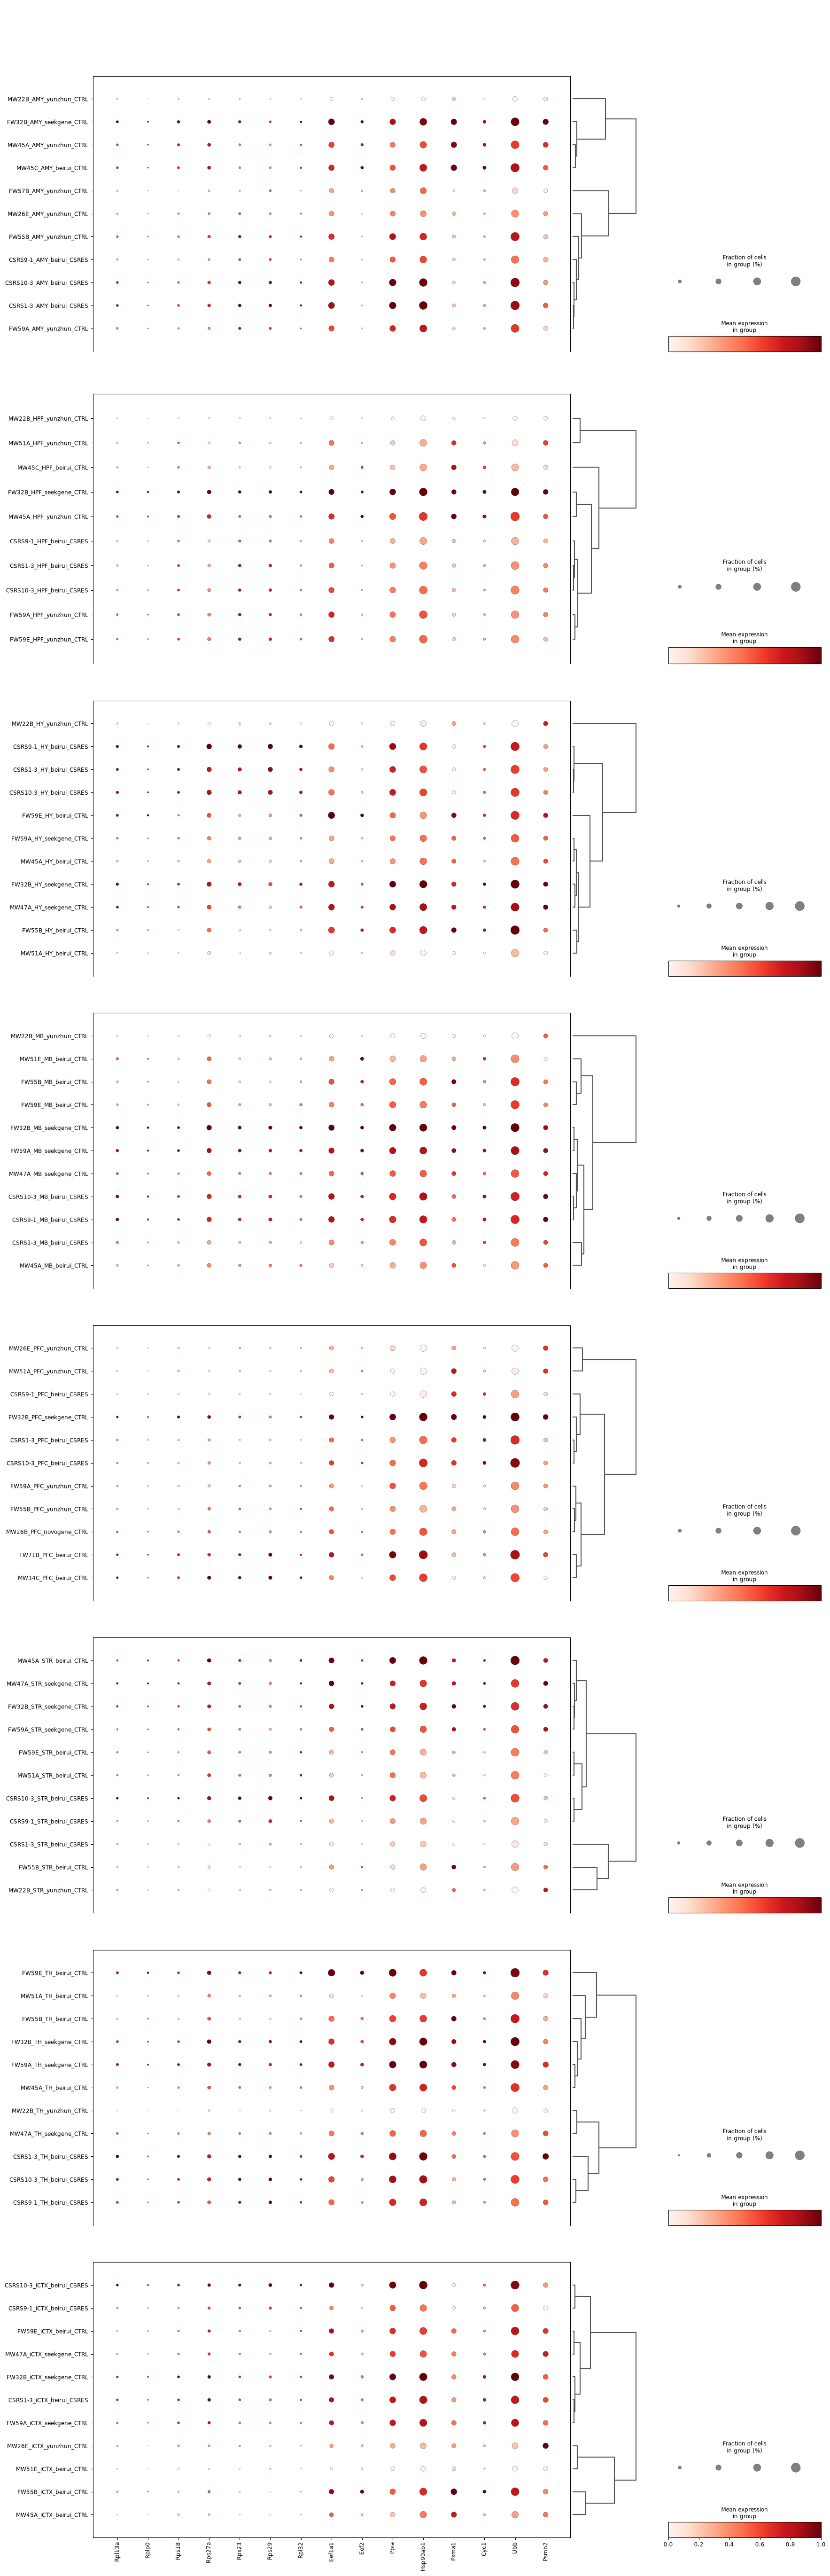

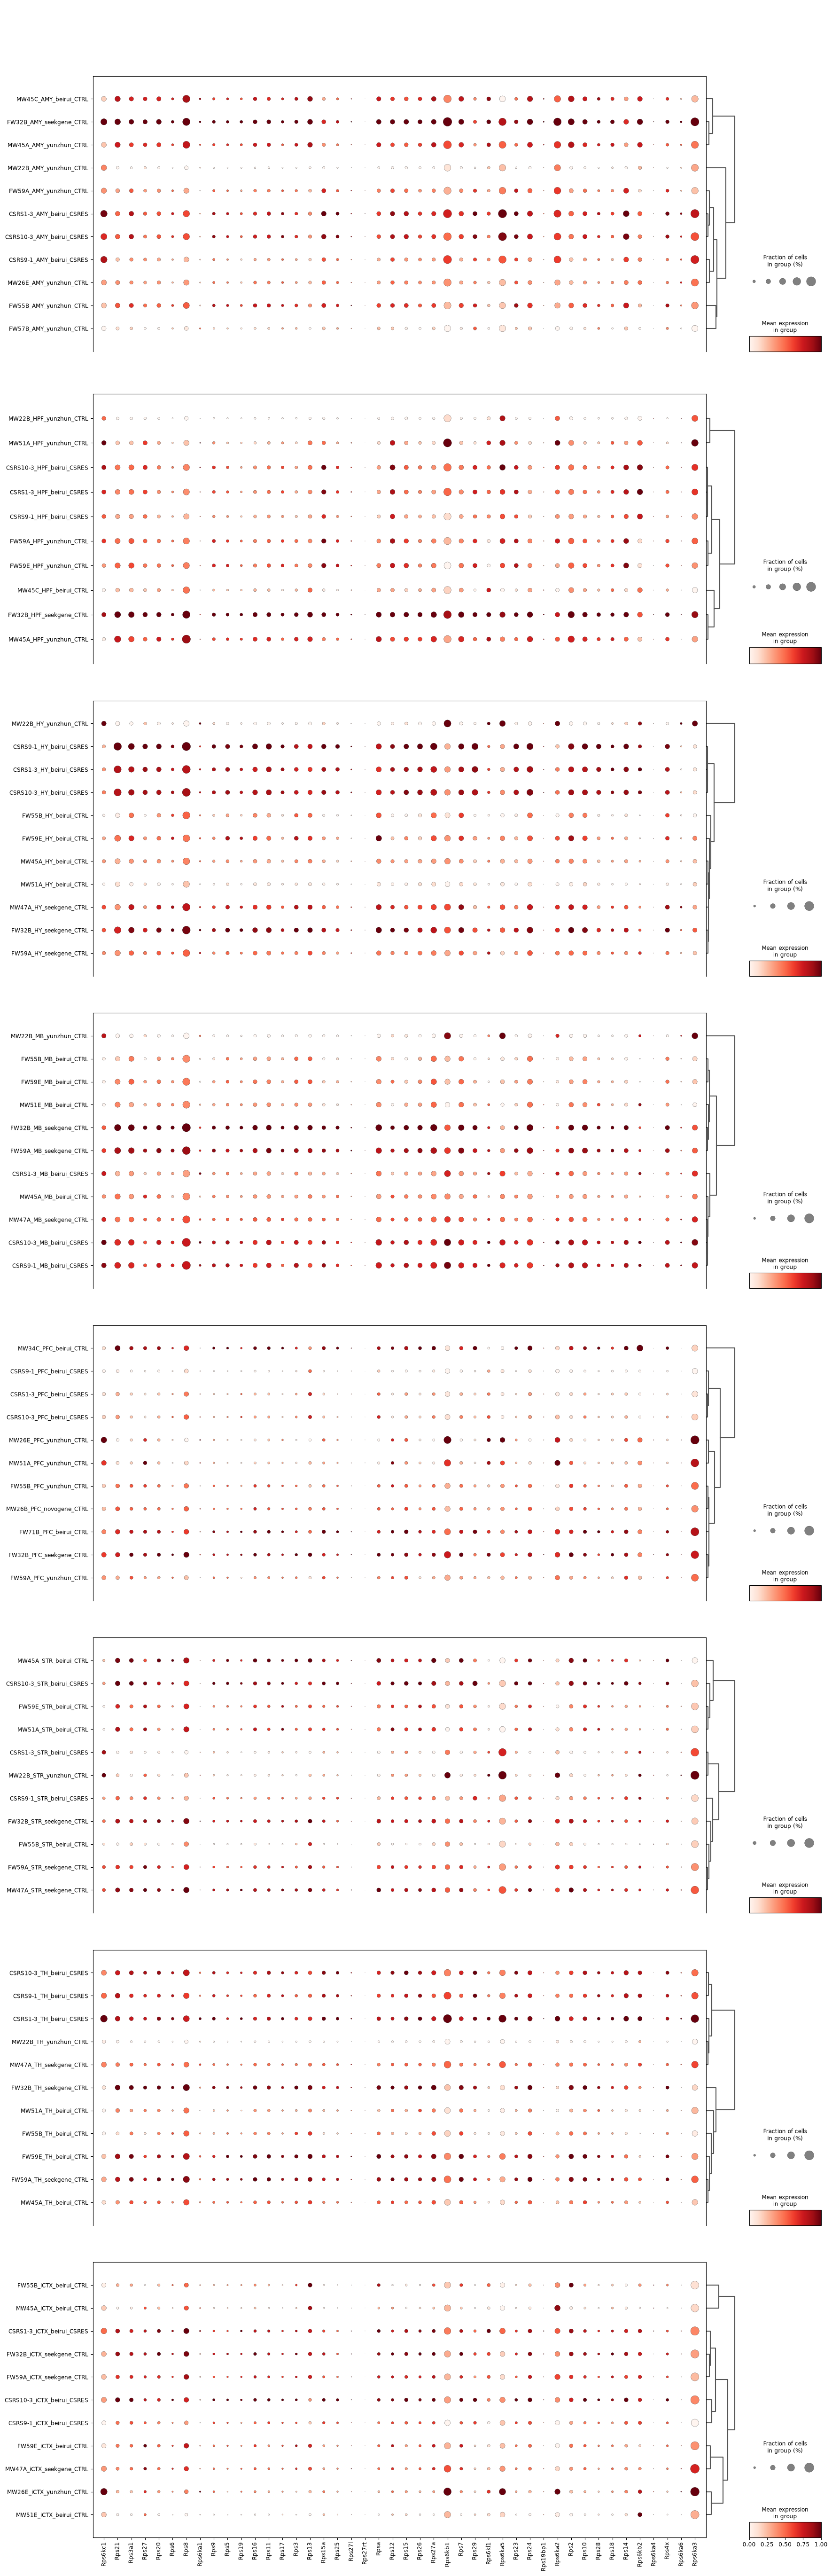

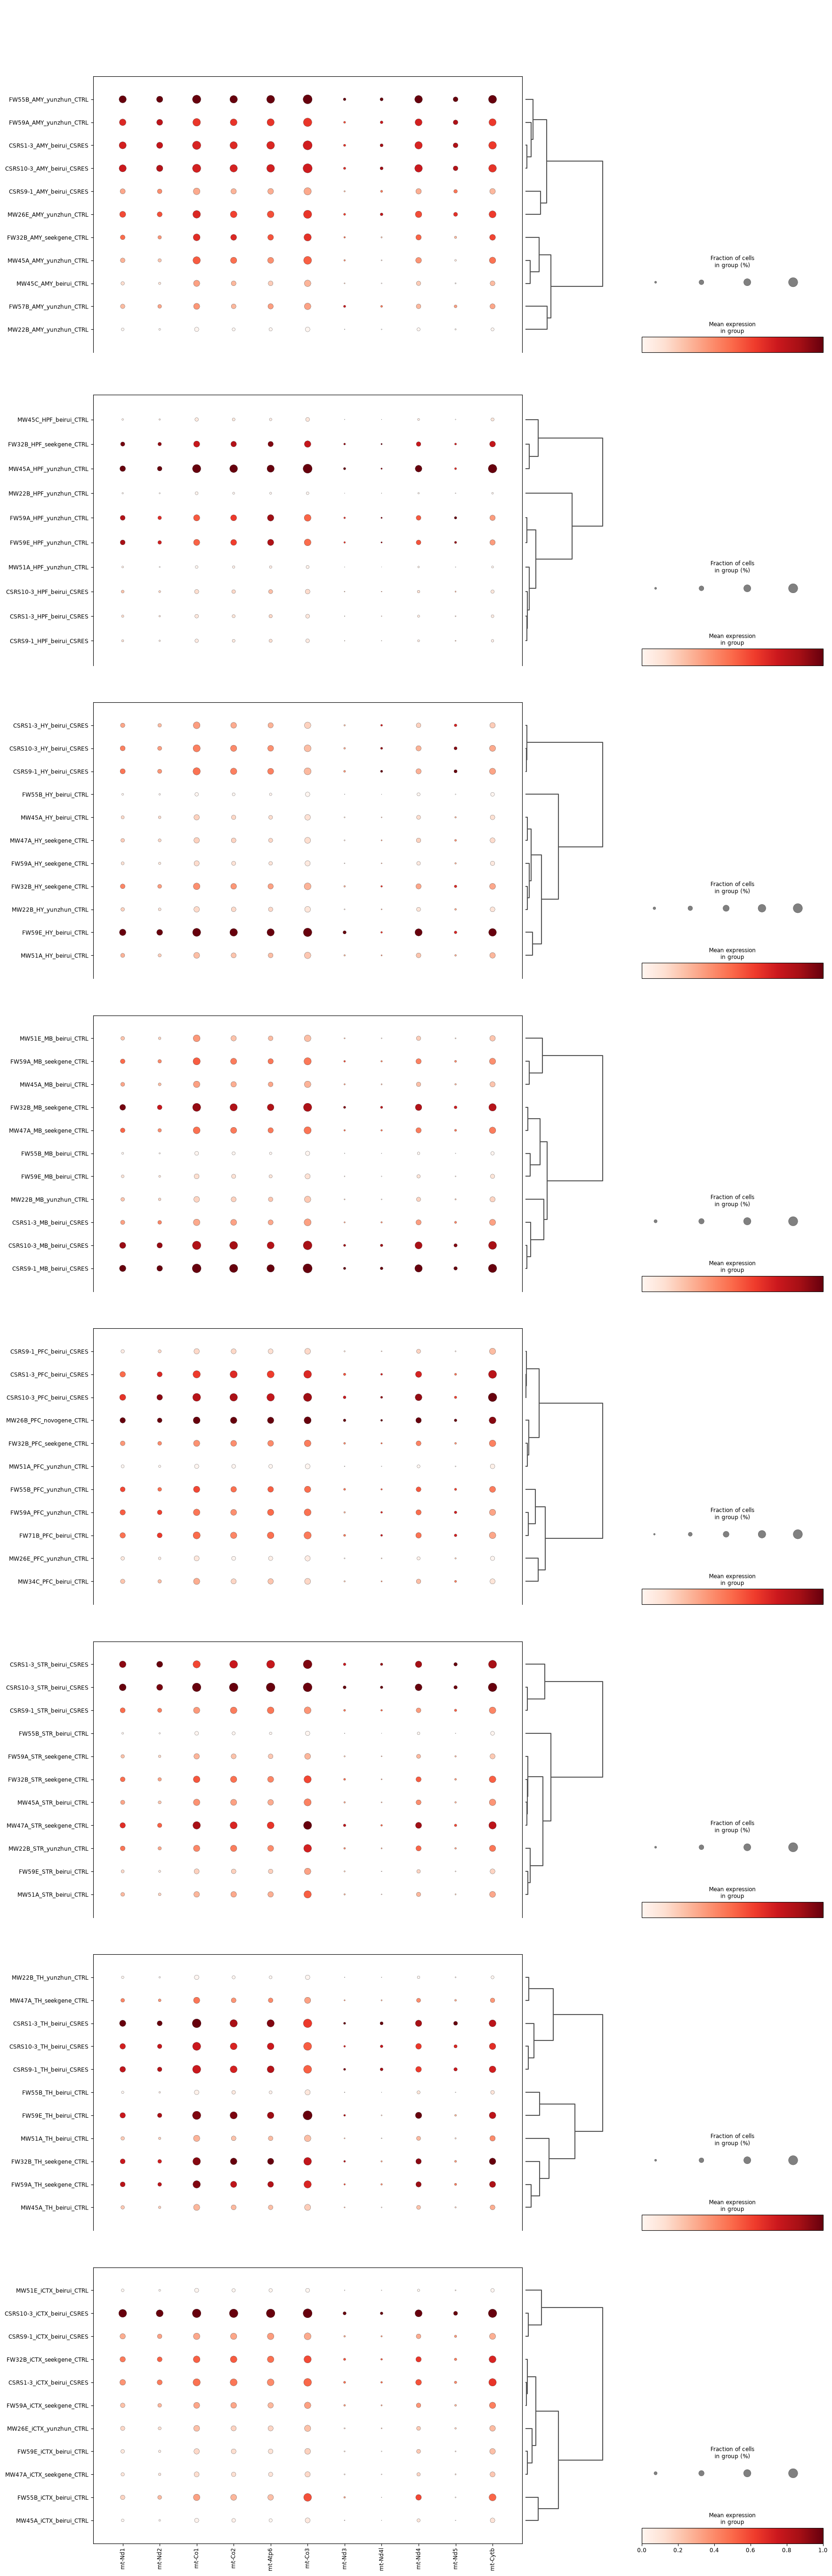

In [19]:
gene_sets = [
    ('hkgene',   hkgene_present),
    ('rps',  rps_genes),
    ('mt',       mt_genes)
]
for name, genes in gene_sets:
    print(f"\n===== {name} =====")
    dotplot_by_region(sub_dict, genes, adata_full=None,
                      groupby='sample_status',
                      layer="genes_plot",
                      out_path=f'{folder}/dotplot_{name}_per_region.pdf')

In [ ]:
df_genegroup = pd.read_excel('/data2st2/junyi/code/sn/data/All_degs_N_v0715FF.xlsx')

In [ ]:
# 按 df_genegroup 中每个 DML2 提取基因集，调用 dotplot_by_region 画图

dml2_col = next((c for c in df_genegroup.columns if c.lower() == 'dml2'), None)
if dml2_col is None:
    raise ValueError("df_genegroup 中找不到 DML2 列")

gene_col_candidates = [
    c for c in df_genegroup.columns
    if c.lower() in {'gene', 'gene_symbol', 'genesymbol', 'symbol', 'gene_name', 'genename'}
]
if len(gene_col_candidates) > 0:
    gene_col = gene_col_candidates[0]
else:
    non_dml2_cols = [c for c in df_genegroup.columns if c != dml2_col]
    if len(non_dml2_cols) == 0:
        raise ValueError("df_genegroup 中没有可用的基因列")
    gene_col = non_dml2_cols[0]
    print(f"[Warning] 未识别标准基因列名，临时使用: {gene_col}")

if 'sample_group' not in ad_all.obs.columns:
    ad_all.obs['sample_group'] = ad_all.obs['sample'].astype(str) + '_' + ad_all.obs['status'].astype(str)
ad_all.obs['sample_group'] = ad_all.obs['sample_group'].astype('category')

if 'order' in globals():
    categories_order = order
else:
    categories_order = ad_all.obs['sample_group'].astype(str).drop_duplicates().tolist()

df_tmp = df_genegroup[[dml2_col, gene_col]].copy()
df_tmp = df_tmp.dropna(subset=[dml2_col, gene_col])
df_tmp[dml2_col] = df_tmp[dml2_col].astype(str).str.strip()
df_tmp[gene_col] = df_tmp[gene_col].astype(str).str.strip()

var_set = set(ad_all.var_names)
min_genes = 3

group_summary = []
for dml2_name, sub_df in df_tmp.groupby(dml2_col):
    raw_genes = pd.unique(sub_df[gene_col]).tolist()
    genes_present = [g for g in raw_genes if g in var_set]

    if len(genes_present) < min_genes:
        print(f"[Skip] {dml2_name}: 匹配到基因数 {len(genes_present)} < {min_genes}")
        continue

    safe_name = ''.join(ch if (ch.isalnum() or ch in ['_', '-']) else '_' for ch in dml2_name)

    # 改用 dotplot_by_region：按脑区分开画、纵向拼接、统一色标
    dotplot_by_region(sub_dict, genes_present, adata_full=ad_all,
                      groupby='sample_status',
                      figsize=(70, 70),
                      show=False,
                      out_path=f'{folder}/dotplot_DML2_{safe_name}_per_region.pdf')

    group_summary.append({
        'DML2': dml2_name,
        'n_genes_raw': len(raw_genes),
        'n_genes_present': len(genes_present),
    })

df_dml2_summary = pd.DataFrame(group_summary).sort_values('n_genes_present', ascending=False)
print(f"完成 DML2 基因集处理: {len(df_dml2_summary)} 个分组")
df_dml2_summary